# Extension Step 1 (v2): Recipe Step Localization with ActionFormer

This notebook implements **Substep 1** of the Task Verification extension, using **ActionFormer** for automatic step localization.

**Goal:**
1.  Use a **ActionFormer**-based model to detect step boundaries (start, end) in recipe videos.
2.  Extract **step-level embeddings** by pooling EgoVLP features within these predicted boundaries.
3.  Save the step features for use in Step 2 (Task Verification).

**Key Features:**
- Implements the full **ActionFormer architecture** (Zhang et al., ECCV 2022)
- Runs on the **complete CaptainCook4D dataset** (384 videos)
- **Multiple hyperparameter configurations** for ablation studies
- **Multiple localization methods** for comprehensive evaluation

**Localization Methods Implemented:**
1. **Ground Truth (GT) Baseline** - Uses `step_annotation.csv` boundaries (upper bound)
2. **ActionFormer** - Full architecture with ConvTransformer backbone + FPN neck
3. **Zero-Shot Clustering** - Unsupervised step discovery using K-Means
4. **Change-Point Detection** - Statistical boundary detection

**ActionFormer Architecture Overview:**
- **Backbone**: ConvTransformer with local self-attention windows
- **Neck**: Feature Pyramid Network (FPN) for multi-scale temporal features
- **Heads**: Classification head + Regression head for boundary prediction

**Reference:**
Zhang et al., "ActionFormer: Localizing Moments of Actions with Transformers", ECCV 2022

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Base paths
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    CODE_BASE = "/content/code"

    # Clone Main Repository (if not exists)
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists(CODE_BASE):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} {CODE_BASE}
        os.chdir(CODE_BASE)
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir(CODE_BASE)

    if CODE_BASE not in sys.path:
        sys.path.append(CODE_BASE)

    # Install requirements
    !pip install -q torcheval

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")
    DRIVE_BASE = "."
    CODE_BASE = os.getcwd()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PATHS ---
if IN_COLAB:
    EGOVLP_FEATURE_DIR = os.path.join(DRIVE_BASE, "features/egovlp")
else:
    EGOVLP_FEATURE_DIR = "data/features/egovlp"

ANNOTATION_PATH = "annotations/annotation_json/step_annotations.json"
SPLIT_PATH = "er_annotations/recordings_combined_splits.json"

print(f"EgoVLP Features: {EGOVLP_FEATURE_DIR}")
print(f"Annotations: {ANNOTATION_PATH}")

Running in Google Colab
Mounted at /content/drive
Cloning repository from https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git...
Cloning into '/content/code'...
remote: Enumerating objects: 883, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 883 (delta 104), reused 93 (delta 88), pack-reused 750 (from 1)
Receiving objects: 100% (883/883), 96.49 MiB | 50.62 MiB/s, done.
Resolving deltas: 100% (478/478), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 12.02 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Su

## 1. Load Data and Annotations

Load the EgoVLP features and ground truth step boundaries for training.

In [2]:
# Load annotations
with open(ANNOTATION_PATH, 'r') as f:
    step_annotations = json.load(f)

with open(SPLIT_PATH, 'r') as f:
    splits = json.load(f)

print(f"Total recordings: {len(step_annotations)}")
print(f"Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

# Helper to load features
def load_features(recording_id, feature_dir=EGOVLP_FEATURE_DIR):
    """Load EgoVLP features for a recording."""
    path = os.path.join(feature_dir, f"{recording_id}_360p_224.npz")
    if os.path.exists(path):
        data = np.load(path)
        return data[list(data.keys())[0]]
    return None

# Check feature availability
available_recordings = []
for rec_id in step_annotations.keys():
    if load_features(rec_id) is not None:
        available_recordings.append(rec_id)

print(f"Recordings with available features: {len(available_recordings)}/{len(step_annotations)}")

Total recordings: 384
Train: 287, Val: 48, Test: 48
Recordings with available features: 384/384


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Feature time base: EgoVLP features are extracted with a 1s window and 1s
# stride (SEGMENT_LENGTH = 1 in colab_feature_extraction.ipynb), so there is
# exactly one feature row per second and row i corresponds to second i.
#
# This was 0.5 while features were extracted at 2s/segment. That value was
# CORRECT for those features, and is wrong for the current 1s features: at 0.5
# every step pools from half the intended row range and only the first half of
# each recording is ever read. If features are ever re-extracted at a different
# stride, this constant must change with them.
FEATURE_FPS = 1.0
print(f"\nUsing Feature FPS: {FEATURE_FPS} (1 feature per second)")



Using Feature FPS: 1.0 (1 feature per second)


In [4]:
# ==============================================================================
# SANITY CHECK: feature rows vs. annotation timestamps (time-base guard)
# ==============================================================================
# This guards the bug class that invalidated the earlier runs of this project.
# Feature rows and step annotations must share a time base: row i must
# correspond to second i / FEATURE_FPS. Nothing enforces that automatically -
# numpy returns an EMPTY slice for an out-of-range index rather than raising,
# so a mismatch shows up as silently-wrong embeddings, not as an error.
#
# Previously features were extracted at 2s/segment while the error-recognition
# dataloader indexed them with raw second-valued timestamps, which produced
# empty slices for 59% of steps and fabricated ground-truth labels downstream.
# Run this before training; it fails loudly instead.

def check_feature_time_base(recording_ids, fps=None, verbose=True):
    """Assert every recording has enough feature rows to cover its last step."""
    fps = FEATURE_FPS if fps is None else fps
    too_short, ratios, checked = [], [], 0

    for rec_id in recording_ids:
        features = load_features(rec_id)
        if features is None:
            continue
        steps = step_annotations[rec_id]['steps']
        ends = [float(s['end_time']) for s in steps if float(s['end_time']) >= 0]
        if not ends:
            continue
        n_rows, last_end = len(features), max(ends)
        needed = last_end * fps           # rows required to reach the last step
        checked += 1
        ratios.append(n_rows / max(needed, 1e-9))
        if n_rows + 1 < needed:           # +1 absorbs floor/rounding at the tail
            too_short.append((rec_id, n_rows, last_end, needed))

    if verbose:
        print(f"Time-base check at FEATURE_FPS={fps} - {checked} recordings")
        if ratios:
            print(f"  rows / rows-needed:  min={min(ratios):.3f}  "
                  f"median={sorted(ratios)[len(ratios)//2]:.3f}  max={max(ratios):.3f}")
            print(f"  (expect >= 1.00; a value near 0.50 means the features are on a "
                  f"2s base while FEATURE_FPS says 1s)")
        if too_short:
            print(f"  {len(too_short)} recording(s) too short:")
            for r, n, le, need in too_short[:5]:
                print(f"    {r}: {n} rows, last step ends {le:.1f}s, needs ~{need:.0f}")
        else:
            print("  OK - every recording covers its last annotated step.")
        # Upper-side warning: a recording can legitimately run past its last step,
        # but ~2x across the board means FEATURE_FPS is too LOW for these features.
        if ratios and sorted(ratios)[len(ratios)//2] > 1.6:
            print(f"  WARNING: median ratio {sorted(ratios)[len(ratios)//2]:.2f} is high - "
                  f"FEATURE_FPS may be too low for the current features.")

    assert not too_short, (
        f"{len(too_short)} recording(s) have too few feature rows at FEATURE_FPS={fps}. "
        f"Features and annotations are on different time bases. Check SEGMENT_LENGTH in "
        f"colab_feature_extraction.ipynb (must be 1) and FEATURE_FPS here (must be 1.0)."
    )
    return checked


check_feature_time_base(available_recordings)


Time-base check at FEATURE_FPS=1.0 - 384 recordings
  rows / rows-needed:  min=0.998  median=1.009  max=1.503
  (expect >= 1.00; a value near 0.50 means the features are on a 2s base while FEATURE_FPS says 1s)
  OK - every recording covers its last annotated step.


384

---
## OPTIONAL: from-scratch ActionFormer (superseded)

**Skip this whole section for normal runs.** Substep 1 now uses the official
pre-trained ActionFormer predictions released with CaptainCook4D (loaded further
down), so nothing here needs to run - and none of it requires a GPU.

These cells are kept because their saved outputs are the evidence for a reported
negative result: training ActionFormer from scratch here reached only **9.19% F1**.
The architecture is a faithful port, but the training objective is not
ActionFormer's - it optimises plain BCE on binary "is this a boundary frame"
labels, supervises only FPN level 0, and never gives the regression head any
gradient, while inference still decodes segment extents from that untrained head.

To re-run this path, set `USE_PRETRAINED_ACTIONFORMER = False` in the loader cell.

---

## 2. ActionFormer Architecture

We implement the full **ActionFormer** architecture from Zhang et al. (ECCV 2022):

**Architecture Components:**
1. **ConvTransformer Backbone**: 1D convolutions + Transformer with local self-attention
2. **Feature Pyramid Network (FPN)**: Multi-scale temporal feature aggregation
3. **Classification Head**: Per-timestep action class prediction
4. **Regression Head**: Boundary offset regression (start/end distances)

**Key Design Choices:**
- Local self-attention with configurable window size (avoids quadratic complexity)
- Multi-scale FPN for handling actions of different durations
- Point-based detection (no anchors/proposals needed)

In [ ]:
# ==============================================================================
# ActionFormer Building Blocks
# Based on: https://github.com/happyharrycn/actionformer_release
# ==============================================================================

import math

def get_sinusoid_encoding(n_position, d_hid):
    """Sinusoidal positional encoding."""
    def get_position_angle_vec(position):
        return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

    sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0).transpose(1, 2)


class MaskedConv1D(nn.Module):
    """1D Convolution with masking support."""

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,
                 dilation=1, groups=1, bias=True, padding_mode='zeros'):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride,
                              padding=padding, dilation=dilation, groups=groups,
                              bias=bias, padding_mode=padding_mode)

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        x = self.conv(x)
        if mask is not None:
            # Adjust mask for stride
            if self.conv.stride[0] > 1:
                mask = mask[:, :, ::self.conv.stride[0]]
            x = x * mask.float()
        return x, mask


class LayerNorm(nn.Module):
    """LayerNorm for (B, C, T) format."""

    def __init__(self, num_channels, eps=1e-5, affine=True):
        super().__init__()
        self.num_channels = num_channels
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.weight = nn.Parameter(torch.ones(1, num_channels, 1))
            self.bias = nn.Parameter(torch.zeros(1, num_channels, 1))

    def forward(self, x):
        # x: (B, C, T)
        mu = x.mean(dim=1, keepdim=True)
        sigma = x.var(dim=1, unbiased=False, keepdim=True).clamp(min=self.eps).sqrt()
        x = (x - mu) / sigma
        if self.affine:
            x = x * self.weight + self.bias
        return x


class LocalMaskedMHCA(nn.Module):
    """Local Multi-Head Cross Attention with window-based attention."""

    def __init__(self, n_embd, n_head, window_size, attn_pdrop=0.0, proj_pdrop=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_embd = n_embd
        self.n_head = n_head
        self.n_channels = n_embd // n_head
        self.scale = 1.0 / math.sqrt(self.n_channels)
        self.window_size = window_size

        # key, query, value projections
        self.key = nn.Conv1d(n_embd, n_embd, 1)
        self.query = nn.Conv1d(n_embd, n_embd, 1)
        self.value = nn.Conv1d(n_embd, n_embd, 1)

        # output projection
        self.proj = nn.Conv1d(n_embd, n_embd, 1)

        # dropouts
        self.attn_drop = nn.Dropout(attn_pdrop)
        self.proj_drop = nn.Dropout(proj_pdrop)

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        B, C, T = x.size()

        # qkv projection
        q = self.query(x)  # (B, C, T)
        k = self.key(x)
        v = self.value(x)

        # reshape for multi-head: (B, nh, C/nh, T)
        q = q.view(B, self.n_head, self.n_channels, T)
        k = k.view(B, self.n_head, self.n_channels, T)
        v = v.view(B, self.n_head, self.n_channels, T)

        # Use local window attention or full attention
        if self.window_size > 0 and T > self.window_size:
            # For simplicity, use chunked attention
            out = self._windowed_attention(q, k, v, mask, T)
        else:
            # Full attention
            attn = (q.transpose(-2, -1) @ k) * self.scale  # (B, nh, T, T)
            if mask is not None:
                mask_float = mask.unsqueeze(1).float()  # (B, 1, 1, T)
                attn = attn.masked_fill(mask_float == 0, float('-inf'))
            attn = F.softmax(attn, dim=-1)
            attn = self.attn_drop(attn)
            out = (attn @ v.transpose(-2, -1)).transpose(-2, -1)  # (B, nh, C/nh, T)

        # merge heads
        out = out.contiguous().view(B, C, T)
        out = self.proj_drop(self.proj(out))

        return out, mask

    def _windowed_attention(self, q, k, v, mask, T):
        """Simplified windowed attention."""
        B, nh, d, _ = q.shape
        ws = min(self.window_size, T)

        # Pad to make divisible by window size
        pad_len = (ws - T % ws) % ws
        if pad_len > 0:
            q = F.pad(q, (0, pad_len))
            k = F.pad(k, (0, pad_len))
            v = F.pad(v, (0, pad_len))

        T_padded = T + pad_len
        num_windows = T_padded // ws

        # Reshape to windows: (B, nh, d, num_windows, ws)
        q = q.view(B, nh, d, num_windows, ws)
        k = k.view(B, nh, d, num_windows, ws)
        v = v.view(B, nh, d, num_windows, ws)

        # Attention within windows
        attn = (q.permute(0, 1, 3, 4, 2) @ k.permute(0, 1, 3, 2, 4)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v.permute(0, 1, 3, 4, 2)).permute(0, 1, 4, 2, 3)  # (B, nh, d, num_windows, ws)
        out = out.contiguous().view(B, nh, d, T_padded)

        # Remove padding
        out = out[..., :T]
        return out


class TransformerBlock(nn.Module):
    """Transformer block with local self-attention and MLP."""

    def __init__(self, n_embd, n_head, n_ds_strides=(1, 1),
                 attn_pdrop=0.0, proj_pdrop=0.0, path_pdrop=0.0,
                 mha_win_size=-1):
        super().__init__()
        self.ln1 = LayerNorm(n_embd)
        self.ln2 = LayerNorm(n_embd)

        # Attention
        window_size = mha_win_size if mha_win_size > 0 else -1
        self.attn = LocalMaskedMHCA(n_embd, n_head, window_size, attn_pdrop, proj_pdrop)

        # MLP
        self.mlp = nn.Sequential(
            nn.Conv1d(n_embd, n_embd * 4, 1),
            nn.GELU(),
            nn.Dropout(proj_pdrop),
            nn.Conv1d(n_embd * 4, n_embd, 1),
            nn.Dropout(proj_pdrop),
        )

        # Downsampling
        self.stride = n_ds_strides[0]
        if self.stride > 1:
            self.pool_skip = nn.MaxPool1d(self.stride, stride=self.stride, padding=self.stride // 2)
        else:
            self.pool_skip = nn.Identity()

        # Drop path
        self.drop_path = path_pdrop

    def forward(self, x, mask):
        # Pre-LN transformer
        out, out_mask = self.attn(self.ln1(x), mask)

        # Residual with pooling
        if self.stride > 1:
            # Downsample attention output and x
            out = self.pool_skip(out)
            x = self.pool_skip(x)
            # Downsample mask to match dimensions
            if out_mask is not None:
                out_mask = self.pool_skip(out_mask.float())

        out_mask_float = out_mask.float() if out_mask is not None else 1.0
        out = x * out_mask_float + out

        # MLP
        out = out + self.mlp(self.ln2(out)) * out_mask_float

        return out, out_mask


class ConvTransformerBackbone(nn.Module):
    """
    ActionFormer Backbone: Convolutions + Transformer with local self-attention.
    """

    def __init__(self, n_in, n_embd, n_head, n_embd_ks=3, max_len=2048,
                 arch=(2, 2, 5), mha_win_size=[-1]*6, scale_factor=2,
                 with_ln=True, attn_pdrop=0.0, proj_pdrop=0.0, path_pdrop=0.0):
        super().__init__()
        self.n_in = n_in
        self.arch = arch
        self.max_len = max_len
        self.scale_factor = scale_factor
        self.mha_win_size = mha_win_size

        # Feature embedding
        self.embd = nn.ModuleList()
        self.embd_norm = nn.ModuleList()
        for idx in range(arch[0]):
            in_dim = n_in if idx == 0 else n_embd
            self.embd.append(MaskedConv1D(in_dim, n_embd, n_embd_ks, padding=n_embd_ks//2))
            self.embd_norm.append(LayerNorm(n_embd) if with_ln else nn.Identity())

        # Positional encoding
        self.pos_embd = get_sinusoid_encoding(max_len, n_embd)

        # Stem transformers (no downsampling)
        self.stem = nn.ModuleList()
        for idx in range(arch[1]):
            self.stem.append(
                TransformerBlock(n_embd, n_head, n_ds_strides=(1, 1),
                                 attn_pdrop=attn_pdrop, proj_pdrop=proj_pdrop,
                                 path_pdrop=path_pdrop, mha_win_size=mha_win_size[0])
            )

        # Branch transformers (with downsampling)
        self.branch = nn.ModuleList()
        for idx in range(arch[2]):
            self.branch.append(
                TransformerBlock(n_embd, n_head, n_ds_strides=(scale_factor, scale_factor),
                                 attn_pdrop=attn_pdrop, proj_pdrop=proj_pdrop,
                                 path_pdrop=path_pdrop, mha_win_size=mha_win_size[1 + idx])
            )

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        B, C, T = x.size()

        # Embedding
        for idx, (embd, norm) in enumerate(zip(self.embd, self.embd_norm)):
            x, mask = embd(x, mask)
            x = F.relu(norm(x))

        # Add positional encoding
        if T <= self.max_len:
            pe = self.pos_embd[:, :, :T].to(x.device)
        else:
            pe = F.interpolate(self.pos_embd.to(x.device), T, mode='linear', align_corners=False)
        x = x + pe * mask.float()

        # Stem (no downsampling)
        for block in self.stem:
            x, mask = block(x, mask)

        # Collect multi-scale outputs
        out_feats = (x,)
        out_masks = (mask,)

        # Branch (with downsampling)
        for block in self.branch:
            x, mask = block(x, mask)
            out_feats = out_feats + (x,)
            out_masks = out_masks + (mask,)

        return out_feats, out_masks


class FPN1D(nn.Module):
    """Feature Pyramid Network for 1D temporal features."""

    def __init__(self, in_channels, out_channel, scale_factor=2.0, with_ln=True):
        super().__init__()
        self.scale_factor = scale_factor

        # Lateral connections
        self.lateral_convs = nn.ModuleList()
        self.fpn_convs = nn.ModuleList()
        self.fpn_norms = nn.ModuleList()

        for i, in_ch in enumerate(in_channels):
            l_conv = MaskedConv1D(in_ch, out_channel, 1)
            fpn_conv = MaskedConv1D(out_channel, out_channel, 3, padding=1, groups=out_channel)
            fpn_norm = LayerNorm(out_channel) if with_ln else nn.Identity()

            self.lateral_convs.append(l_conv)
            self.fpn_convs.append(fpn_conv)
            self.fpn_norms.append(fpn_norm)

    def forward(self, inputs, fpn_masks):
        # Build laterals
        laterals = []
        for i, (lat_conv, (feat, mask)) in enumerate(zip(self.lateral_convs, zip(inputs, fpn_masks))):
            lat, _ = lat_conv(feat, mask)
            laterals.append(lat)

        # Top-down pathway
        for i in range(len(laterals) - 1, 0, -1):
            # Upsample to match dimension of previous level
            # This handles cases where size is not exactly 2x due to odd dimensions/padding
            target_size = laterals[i - 1].shape[-1]
            laterals[i - 1] = laterals[i - 1] + F.interpolate(
                laterals[i], size=target_size, mode='nearest'
            )

        # Output convolutions
        fpn_feats = []
        new_masks = []
        for i, (lat, mask) in enumerate(zip(laterals, fpn_masks)):
            out, new_mask = self.fpn_convs[i](lat, mask)
            out = self.fpn_norms[i](out)
            fpn_feats.append(out)
            new_masks.append(new_mask)

        return tuple(fpn_feats), tuple(new_masks)


class PointGenerator(nn.Module):
    """Generate point coordinates for each FPN level."""

    def __init__(self, max_seq_len, fpn_strides, regression_range):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.fpn_strides = fpn_strides
        self.regression_range = regression_range

    def forward(self, fpn_feats):
        points = []
        for l, feat in enumerate(fpn_feats):
            T = feat.size(-1)
            stride = self.fpn_strides[l]
            reg_range = self.regression_range[l]

            # Generate points at center of each temporal location
            pts = torch.arange(0, T, dtype=torch.float32, device=feat.device)
            pts = pts * stride + stride / 2

            # Stack: (T, 4) - [time, stride, reg_min, reg_max]
            pts_info = torch.stack([
                pts,
                torch.full_like(pts, stride),
                torch.full_like(pts, reg_range[0]),
                torch.full_like(pts, reg_range[1])
            ], dim=-1)
            points.append(pts_info)

        return points


class ActionFormer(nn.Module):
    """
    Full ActionFormer Model for Temporal Action Localization.

    Reference: Zhang et al., "ActionFormer: Localizing Moments of Actions
    with Transformers", ECCV 2022.

    Architecture:
    1. ConvTransformer Backbone: Local self-attention with multi-scale outputs
    2. FPN Neck: Feature pyramid for multi-scale temporal features
    3. Classification Head: Per-timestep class prediction
    4. Regression Head: Boundary offset regression
    """

    def __init__(
        self,
        input_dim=256,           # Input feature dimension (EgoVLP=256)
        embd_dim=256,            # Embedding dimension
        n_head=4,                # Number of attention heads
        embd_kernel_size=3,      # Kernel size for embedding conv
        max_seq_len=2500,        # Maximum sequence length. Raised from 2048: at
                                 # 1s/1s the longest recording is ~2460 rows, and
                                 # beyond max_seq_len the sinusoidal positional
                                 # encoding falls back to F.interpolate rather than
                                 # the exact table (works, but is a degraded path).
        arch=(2, 2, 5),          # (#embed_convs, #stem_transformers, #branch_transformers)
        mha_win_size=19,         # Local attention window size (-1 for global)
        scale_factor=2,          # Downsampling factor between FPN levels
        fpn_dim=256,             # FPN output dimension
        head_dim=256,            # Head hidden dimension
        num_classes=1,           # Number of action classes (1 for binary boundary)
        regression_range=None,   # Regression range for each FPN level
        attn_pdrop=0.0,
        proj_pdrop=0.0,
        path_pdrop=0.1,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.max_seq_len = max_seq_len
        self.scale_factor = scale_factor

        # Compute FPN strides
        self.fpn_strides = [scale_factor ** i for i in range(arch[2] + 1)]

        # Default regression range - Extended to support deeper architectures
        if regression_range is None:
            regression_range = [
                (0, 4), (4, 8), (8, 16), (16, 32),
                (32, 64), (64, 128), (128, 256), (256, 512), (512, 1024)
            ]

        # Select ranges for the current number of levels
        self.regression_range = regression_range[:arch[2] + 1]

        # Ensure the last level handles all larger scales
        if len(self.regression_range) > 0:
             self.regression_range[-1] = (self.regression_range[-1][0], float('inf'))

        # Window sizes for each level
        if isinstance(mha_win_size, int):
            mha_win_size = [mha_win_size] * (1 + arch[2])

        # Backbone
        self.backbone = ConvTransformerBackbone(
            n_in=input_dim,
            n_embd=embd_dim,
            n_head=n_head,
            n_embd_ks=embd_kernel_size,
            max_len=max_seq_len,
            arch=arch,
            mha_win_size=mha_win_size,
            scale_factor=scale_factor,
            attn_pdrop=attn_pdrop,
            proj_pdrop=proj_pdrop,
            path_pdrop=path_pdrop,
        )

        # FPN Neck
        fpn_in_channels = [embd_dim] * (arch[2] + 1)
        self.neck = FPN1D(fpn_in_channels, fpn_dim, scale_factor=scale_factor)

        # Point generator
        self.point_generator = PointGenerator(max_seq_len, self.fpn_strides, self.regression_range)

        # Classification head (multi-level)
        self.cls_head = nn.ModuleList()
        for _ in range(len(self.fpn_strides)):
            self.cls_head.append(nn.Sequential(
                nn.Conv1d(fpn_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, num_classes, 3, padding=1),
            ))

        # Regression head (multi-level)
        self.reg_head = nn.ModuleList()
        for _ in range(len(self.fpn_strides)):
            self.reg_head.append(nn.Sequential(
                nn.Conv1d(fpn_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, 2, 3, padding=1),  # Start and end offsets
                nn.ReLU(),  # Offsets should be positive
            ))

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv1d)):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x, mask=None):
        """
        Args:
            x: (B, T, C) or (B, C, T) - Input features
            mask: (B, T) - Optional mask for valid positions

        Returns:
            out_cls_logits: List of (B, num_classes, T_i) for each FPN level
            out_offsets: List of (B, 2, T_i) for each FPN level
            points: List of (T_i, 4) point info for each FPN level
        """
        B = x.size(0)

        # Ensure (B, C, T) format
        if x.dim() == 3 and x.size(-1) != self.input_dim and x.size(1) == self.input_dim:
            pass  # Already (B, C, T)
        elif x.dim() == 3 and x.size(-1) == self.input_dim:
            x = x.transpose(1, 2)  # (B, T, C) -> (B, C, T)

        T = x.size(-1)

        # Create mask if not provided
        if mask is None:
            mask = torch.ones(B, 1, T, device=x.device, dtype=torch.bool)
        elif mask.dim() == 2:
            mask = mask.unsqueeze(1)  # (B, T) -> (B, 1, T)

        # Backbone
        feats, masks = self.backbone(x, mask)

        # FPN
        fpn_feats, fpn_masks = self.neck(feats, masks)

        # Generate points
        points = self.point_generator(fpn_feats)

        # Apply heads
        out_cls_logits = []
        out_offsets = []

        for l, (feat, fpn_mask) in enumerate(zip(fpn_feats, fpn_masks)):
            cls_logits = self.cls_head[l](feat)
            offsets = self.reg_head[l](feat)

            out_cls_logits.append(cls_logits)
            out_offsets.append(offsets)

        return out_cls_logits, out_offsets, points, fpn_masks

    def predict_boundaries(self, x, mask=None, threshold=0.5, nms_threshold=0.5):
        """
        Predict step boundaries from features.

        Returns:
            List of (start_time, end_time, score) tuples
        """
        self.eval()
        with torch.no_grad():
            out_cls, out_offsets, points, fpn_masks = self.forward(x, mask)

        all_segments = []
        all_scores = []

        for l, (cls_logits, offsets, pts, m) in enumerate(zip(out_cls, out_offsets, points, fpn_masks)):
            # cls_logits: (B, 1, T), offsets: (B, 2, T)
            probs = torch.sigmoid(cls_logits).squeeze(1)  # (B, T)

            # Get predictions above threshold
            batch_size = probs.size(0)
            for b in range(batch_size):
                prob = probs[b]  # (T,)
                offset = offsets[b]  # (2, T)
                point = pts  # (T, 4)

                above_thresh = prob > threshold
                if not above_thresh.any():
                    continue

                # Get center points and offsets
                centers = point[above_thresh, 0]  # Time positions
                stride = point[above_thresh, 1]
                start_offset = offset[0, above_thresh]
                end_offset = offset[1, above_thresh]

                # Compute segment boundaries
                starts = centers - start_offset * stride
                ends = centers + end_offset * stride
                scores = prob[above_thresh]

                all_segments.append(torch.stack([starts, ends], dim=-1))
                all_scores.append(scores)

        if not all_segments:
            return []

        # Concatenate all predictions
        all_segments = torch.cat(all_segments, dim=0)
        all_scores = torch.cat(all_scores, dim=0)

        # Apply NMS
        segments_np = all_segments.cpu().numpy()
        scores_np = all_scores.cpu().numpy()

        # Simple NMS
        keep = self._nms(segments_np, scores_np, nms_threshold)

        results = []
        for idx in keep:
            results.append({
                'segment': [float(segments_np[idx, 0]), float(segments_np[idx, 1])],
                'score': float(scores_np[idx])
            })

        return sorted(results, key=lambda x: x['segment'][0])

    def _nms(self, segments, scores, threshold):
        """Non-maximum suppression for temporal segments."""
        if len(segments) == 0:
            return []

        # Sort by score
        order = scores.argsort()[::-1]
        keep = []

        while order.size > 0:
            i = order[0]
            keep.append(i)

            # Compute IoU with rest
            xx1 = np.maximum(segments[i, 0], segments[order[1:], 0])
            xx2 = np.minimum(segments[i, 1], segments[order[1:], 1])
            inter = np.maximum(0, xx2 - xx1)

            len_i = segments[i, 1] - segments[i, 0]
            len_rest = segments[order[1:], 1] - segments[order[1:], 0]
            union = len_i + len_rest - inter

            iou = inter / (union + 1e-8)

            # Keep segments with low IoU
            inds = np.where(iou <= threshold)[0]
            order = order[inds + 1]

        return keep


print("ActionFormer model defined (full architecture).")
print("Components: ConvTransformerBackbone + FPN1D + Classification/Regression Heads")

ActionFormer model defined (full architecture).
Components: ConvTransformerBackbone + FPN1D + Classification/Regression Heads


In [ ]:
class StepLocalizationDataset(Dataset):
    """
    Dataset for training step boundary detection.
    Creates binary labels: 1 at step boundary frames, 0 elsewhere.
    """

    # max_len: at 1s/1s the longest recording is ~2460 rows (it was ~1230 at 2s),
    # and 8 of 384 recordings exceed 2000 - those would be silently truncated,
    # dropping exactly the late steps the time-base fix restored.
    # feature_fps default was 30 (the video frame rate), which is never correct
    # for indexing feature ROWS; the rows are 1 per second.
    def __init__(self, recording_ids, annotations, feature_dir, max_len=2500, feature_fps=1.0):
        self.recording_ids = recording_ids
        self.annotations = annotations
        self.feature_dir = feature_dir
        self.max_len = max_len
        self.feature_fps = feature_fps

        # Filter to only recordings with features
        self.valid_ids = []
        for rec_id in recording_ids:
            if load_features(rec_id, feature_dir) is not None:
                self.valid_ids.append(rec_id)

        print(f"Dataset: {len(self.valid_ids)} valid recordings out of {len(recording_ids)}")

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        rec_id = self.valid_ids[idx]

        # Load features
        features = load_features(rec_id, self.feature_dir)
        seq_len = len(features)

        # Create boundary labels (1 at step start/end, 0 elsewhere)
        boundary_labels = np.zeros(seq_len, dtype=np.float32)

        steps = self.annotations[rec_id]['steps']
        for step in steps:
            start_frame = int(float(step['start_time']) * self.feature_fps)
            end_frame = int(float(step['end_time']) * self.feature_fps)

            # Mark boundaries (with small tolerance window)
            tolerance = 3  # frames
            for offset in range(-tolerance, tolerance + 1):
                if 0 <= start_frame + offset < seq_len:
                    boundary_labels[start_frame + offset] = 1.0
                if 0 <= end_frame + offset < seq_len:
                    boundary_labels[end_frame + offset] = 1.0

        # Truncate or pad
        if seq_len > self.max_len:
            features = features[:self.max_len]
            boundary_labels = boundary_labels[:self.max_len]
            seq_len = self.max_len

        return {
            'recording_id': rec_id,
            'features': torch.tensor(features, dtype=torch.float32),
            'boundary_labels': torch.tensor(boundary_labels, dtype=torch.float32),
            'seq_len': seq_len
        }

def collate_fn(batch):
    """Collate with padding."""
    max_len = max(item['seq_len'] for item in batch)

    features = []
    labels = []
    masks = []
    rec_ids = []

    for item in batch:
        seq_len = item['seq_len']
        feat = item['features']
        label = item['boundary_labels']

        # Pad
        if seq_len < max_len:
            pad_len = max_len - seq_len
            feat = F.pad(feat, (0, 0, 0, pad_len))
            label = F.pad(label, (0, pad_len))

        features.append(feat)
        labels.append(label)

        # Create mask (1 for valid, 0 for padding)
        mask = torch.zeros(max_len)
        mask[:seq_len] = 1
        masks.append(mask)
        rec_ids.append(item['recording_id'])

    return {
        'recording_ids': rec_ids,
        'features': torch.stack(features),
        'boundary_labels': torch.stack(labels),
        'masks': torch.stack(masks)
    }

print("Dataset class defined.")

Dataset class defined.


In [ ]:
# ==============================================================================
# Dataset Setup - Full CaptainCook4D Dataset (384 Videos)
# ==============================================================================

print("=" * 60)
print("DATASET SETUP - Full CaptainCook4D Dataset")
print("=" * 60)

# Get all available recordings across splits
all_train_ids = [r for r in splits['train'] if r in available_recordings]
all_val_ids = [r for r in splits['val'] if r in available_recordings]
all_test_ids = [r for r in splits['test'] if r in available_recordings]

print(f"Train recordings: {len(all_train_ids)}")
print(f"Val recordings: {len(all_val_ids)}")
print(f"Test recordings: {len(all_test_ids)}")
print(f"Total: {len(all_train_ids) + len(all_val_ids) + len(all_test_ids)}")

# FEATURE_FPS is defined in the configuration cell near the top.

train_dataset = StepLocalizationDataset(
    all_train_ids, step_annotations, EGOVLP_FEATURE_DIR, feature_fps=FEATURE_FPS
)
val_dataset = StepLocalizationDataset(
    all_val_ids, step_annotations, EGOVLP_FEATURE_DIR, feature_fps=FEATURE_FPS
)
test_dataset = StepLocalizationDataset(
    all_test_ids, step_annotations, EGOVLP_FEATURE_DIR, feature_fps=FEATURE_FPS
)

# DataLoaders
BATCH_SIZE = 4  # Adjust based on GPU memory
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DATASET SETUP - Full CaptainCook4D Dataset
Train recordings: 287
Val recordings: 48
Test recordings: 48
Total: 383

Using Feature FPS: 0.5 (Corrected from default 30)
Dataset: 287 valid recordings out of 287
Dataset: 48 valid recordings out of 48
Dataset: 48 valid recordings out of 48

Train batches: 72
Val batches: 12
Test batches: 12


In [ ]:
# ==============================================================================
# Configuration for the from-scratch ActionFormer
# ==============================================================================
# This is the ALTERNATIVE localization path. The reported pipeline uses the official
# pre-trained CaptainCook4D ActionFormer predictions (USE_PRETRAINED_ACTIONFORMER),
# which cover 119 of 384 recordings. This path trains a model on the EgoVLP features
# instead, and exists so that the from-scratch result can be reproduced.
#
# Its localization quality is low (F1 9.19%). The cause is the training objective
# rather than the architecture: the loss is plain BCE over binary "is this a boundary
# frame" labels, only FPN level 0 is supervised, and the regression head receives no
# gradient even though inference decodes segment extents from it.
# ==============================================================================

TRAIN_ACTIONFORMER_FROM_SCRATCH = True

if TRAIN_ACTIONFORMER_FROM_SCRATCH:
    print("=" * 70)
    print("Training ActionFormer from scratch on EgoVLP features")
    print("=" * 70)

# Best ActionFormer configuration
BEST_ACTIONFORMER_CONFIG = {
    "input_dim": 256,          # EgoVLP feature dimension (fixed)
    "embd_dim": 256,           # Best from experiments
    "n_head": 4,
    "arch": (2, 2, 5),
    "mha_win_size": 19,
    "scale_factor": 2,
    "fpn_dim": 256,
    "head_dim": 256,
    "attn_pdrop": 0.1,
    "proj_pdrop": 0.1,
    "path_pdrop": 0.1,
    "weight_decay": 0.05,
    "pos_weight": 2.0,
    "batch_size": 16,
    "lr": 5e-4,
    "num_epochs": 30,
}

# Best clustering configuration
BEST_CLUSTERING_CONFIG = {
    "method": "kmeans",
    "n_clusters": None,  # Auto-detect using silhouette score
    "n_clusters_range": (5, 15),  # Search range for auto-detection
}

print(f"\nActionFormer Config: bs={BEST_ACTIONFORMER_CONFIG['batch_size']}, "
      f"lr={BEST_ACTIONFORMER_CONFIG['lr']}, embd_dim={BEST_ACTIONFORMER_CONFIG['embd_dim']}")
print(f"Clustering Config: {BEST_CLUSTERING_CONFIG['method']}, n_clusters=auto")

⚡ QUICK PIPELINE MODE ENABLED
Using pre-determined best configurations from previous experiments.
This will skip the exhaustive grid search (~24+ hours).

ActionFormer Config: bs=16, lr=0.0005, embd_dim=256
Clustering Config: kmeans, n_clusters=auto


## 3.1 Pipeline Integration: Export Step Embeddings for Step 2

This section creates step embeddings using **ActionFormer's predicted boundaries** instead of GT boundaries, enabling comparison of pipeline performance with automatic localization vs. oracle GT.

In [ ]:
# ==============================================================================
# From-scratch ActionFormer: final training run
# ==============================================================================
# Trains the configuration below with extended epochs so that its segments can be fed
# to Substep 2.
#
# Two different F1 scores appear in this notebook and they are not comparable:
#   - the value printed below (~0.67) is per-frame boundary classification F1, the
#     proxy quantity the BCE objective actually optimises;
#   - the localization F1 reported by the tIoU evaluation cell is 0.0919, and that is
#     the number the task is measured by.
# A proxy that reaches 0.67 while the task metric sits at 0.09 is the clearest single
# piece of evidence that the objective, not the architecture, is what is wrong here.
# ==============================================================================

import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

BEST_CONFIG = {
    "input_dim": 256,          # EgoVLP feature dimension (fixed)
    "embd_dim": 256,
    "n_head": 4,
    "arch": (2, 2, 5),
    "mha_win_size": 19,
    "scale_factor": 2,
    "fpn_dim": 256,
    "head_dim": 256,
    "attn_pdrop": 0.1,
    "proj_pdrop": 0.1,
    "path_pdrop": 0.1,
    "weight_decay": 0.05,
    "pos_weight": 5.0,
    "batch_size": 16,
    "lr": 5e-4,
    "num_epochs": 30,
    "warmup_epochs": 5,
}

print("=" * 70)
print("BEST CONFIGURATION TRAINING FOR PIPELINE")
print("=" * 70)
print(f"Config: bs={BEST_CONFIG['batch_size']}, lr={BEST_CONFIG['lr']}, embd={BEST_CONFIG['embd_dim']}, dropout={BEST_CONFIG['attn_pdrop']}")
print(f"Epochs: {BEST_CONFIG['num_epochs']}")
print("=" * 70)

# Create model
best_model = ActionFormer(
    input_dim=BEST_CONFIG["input_dim"],
    embd_dim=BEST_CONFIG["embd_dim"],
    n_head=BEST_CONFIG["n_head"],
    arch=BEST_CONFIG["arch"],
    mha_win_size=BEST_CONFIG["mha_win_size"],
    scale_factor=BEST_CONFIG["scale_factor"],
    fpn_dim=BEST_CONFIG["fpn_dim"],
    head_dim=BEST_CONFIG["head_dim"],
    num_classes=1,
    attn_pdrop=BEST_CONFIG["attn_pdrop"],
    proj_pdrop=BEST_CONFIG["proj_pdrop"],
    path_pdrop=BEST_CONFIG["path_pdrop"],
).to(device)

# Create dataloaders
best_train_loader = DataLoader(train_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn)
best_val_loader = DataLoader(val_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(best_model.parameters(), lr=BEST_CONFIG['lr'], weight_decay=BEST_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=BEST_CONFIG['num_epochs'])
pos_weight_tensor = torch.tensor([BEST_CONFIG["pos_weight"]]).to(device)

# Training tracking
best_f1 = 0
best_epoch = 0
train_history = []
val_history = []

# Evaluation function
def evaluate_best(model, loader, device, pos_weight):
    model.eval()
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for batch in loader:
            features = batch['features'].to(device)
            labels = batch['boundary_labels'].to(device)
            masks = batch['masks'].to(device)

            out_cls, _, _, _ = model(features)
            cls_logits = out_cls[0].squeeze(1)

            if cls_logits.size(-1) != labels.size(-1):
                labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            else:
                labels_i, masks_i = labels, masks

            probs = torch.sigmoid(cls_logits)
            for i in range(features.size(0)):
                seq_len = int(masks_i[i].sum())
                all_preds.extend(probs[i, :seq_len].cpu().numpy())
                all_labels_list.extend(labels_i[i, :seq_len].cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)
    binary_preds = (all_preds > 0.5).astype(float)

    tp = ((binary_preds == 1) & (all_labels_arr == 1)).sum()
    fp = ((binary_preds == 1) & (all_labels_arr == 0)).sum()
    fn = ((binary_preds == 0) & (all_labels_arr == 1)).sum()
    tn = ((binary_preds == 0) & (all_labels_arr == 0)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return f1, precision, recall, accuracy

# Training loop
start_time = time.time()
for epoch in range(BEST_CONFIG['num_epochs']):
    best_model.train()
    epoch_loss = 0

    for batch in best_train_loader:
        features = batch['features'].to(device)
        labels = batch['boundary_labels'].to(device)
        masks = batch['masks'].to(device)

        optimizer.zero_grad()
        out_cls, _, _, _ = best_model(features)
        cls_logits = out_cls[0].squeeze(1)

        if cls_logits.size(-1) != labels.size(-1):
            labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
        else:
            labels_i, masks_i = labels, masks

        loss = F.binary_cross_entropy_with_logits(
            cls_logits, labels_i,
            pos_weight=pos_weight_tensor.expand_as(cls_logits),
            reduction='none'
        )
        loss = (loss * masks_i).sum() / (masks_i.sum() + 1e-8)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    train_history.append(epoch_loss / len(best_train_loader))

    if (epoch + 1) % 1 == 0:
        val_f1, val_prec, val_rec, val_acc = evaluate_best(best_model, best_val_loader, device, pos_weight_tensor)
        val_history.append({'epoch': epoch+1, 'f1': val_f1, 'prec': val_prec, 'rec': val_rec, 'acc': val_acc})

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch + 1
            # Save best model
            torch.save({
                'model_state_dict': best_model.state_dict(),
                'config': BEST_CONFIG,
                'best_f1': best_f1,
                'best_epoch': best_epoch,
            }, 'actionformer_best_for_pipeline.pt')

        print(f"Epoch {epoch+1:3d}: Loss={train_history[-1]:.4f}, Val F1={val_f1:.4f}, Prec={val_prec:.4f}, Rec={val_rec:.4f}, Acc={val_acc:.4f}")

elapsed = time.time() - start_time
print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best F1: {best_f1:.4f} at epoch {best_epoch}")
print(f"Total time: {elapsed/60:.1f} minutes")
print(f"Model saved to: actionformer_best_for_pipeline.pt")
print("\nThis model will be used for Step 2 pipeline integration.")

BEST CONFIGURATION TRAINING FOR PIPELINE
Config: bs=16, lr=0.0005, embd=256, dropout=0.1
Epochs: 30
Epoch   1: Loss=1.3090, Val F1=0.5879, Prec=0.4453, Rec=0.8646, Acc=0.6224
Epoch   2: Loss=1.1093, Val F1=0.5690, Prec=0.4072, Rec=0.9441, Acc=0.5545
Epoch   3: Loss=1.0423, Val F1=0.6021, Prec=0.4487, Rec=0.9152, Acc=0.6233
Epoch   4: Loss=0.9720, Val F1=0.6217, Prec=0.4765, Rec=0.8942, Acc=0.6611
Epoch   5: Loss=0.9097, Val F1=0.6074, Prec=0.4505, Rec=0.9316, Acc=0.6248
Epoch   6: Loss=0.8840, Val F1=0.6592, Prec=0.5462, Rec=0.8309, Acc=0.7323
Epoch   7: Loss=0.8365, Val F1=0.6573, Prec=0.5292, Rec=0.8674, Acc=0.7183
Epoch   8: Loss=0.7905, Val F1=0.6479, Prec=0.5121, Rec=0.8818, Acc=0.7015
Epoch   9: Loss=0.7406, Val F1=0.6328, Prec=0.4840, Rec=0.9140, Acc=0.6697
Epoch  10: Loss=0.7095, Val F1=0.6517, Prec=0.5254, Rec=0.8577, Acc=0.7144
Epoch  11: Loss=0.6241, Val F1=0.6582, Prec=0.5397, Rec=0.8434, Acc=0.7271
Epoch  12: Loss=0.5862, Val F1=0.6612, Prec=0.5600, Rec=0.8072, Acc=0.7424


## 4. Alternative Localization Methods

In addition to the learned ActionFormer model, we implement **unsupervised baselines** for comparison:

1. **ActionFormer (Learned)** - Trained boundary detector (above)
2. **Zero-Shot Clustering** - Unsupervised step discovery using K-Means
3. **Change-Point Detection** - Statistical boundary detection using feature variance
4. **Sliding Window + Threshold** - Simple baseline using confidence scores

In [ ]:
# ==============================================================================
# ALTERNATIVE LOCALIZATION METHODS
# ==============================================================================

# Method 1: Load BEST trained ActionFormer from experiments
import glob

best_checkpoint = None
best_f1 = 0

for ckpt_file in glob.glob("actionformer_*.pt"):
    try:
        ckpt = torch.load(ckpt_file, map_location=device, weights_only=False)
        if ckpt.get('best_f1', 0) > best_f1:
            best_f1 = ckpt['best_f1']
            best_checkpoint = ckpt_file
    except:
        continue

if best_checkpoint:
    checkpoint = torch.load(best_checkpoint, map_location=device, weights_only=False)
    config = checkpoint['config']

    # Reinitialize model with the best config
    model = ActionFormer(
        input_dim=config["input_dim"],
        embd_dim=config["embd_dim"],
        n_head=config["n_head"],
        arch=config["arch"],
        mha_win_size=config["mha_win_size"],
        scale_factor=config["scale_factor"],
        fpn_dim=config["fpn_dim"],
        head_dim=config["head_dim"],
        num_classes=1,
        attn_pdrop=config["attn_pdrop"],
        proj_pdrop=config["proj_pdrop"],
        path_pdrop=config["path_pdrop"],
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded BEST ActionFormer model: {best_checkpoint}")
    print(f"  Best F1: {best_f1:.4f}")
    print(f"  Config: batch_size={config.get('batch_size')}, lr={config.get('lr')}")
else:
    print("Warning: No checkpoint found, using current model state")

model.eval()

# Method 2: Zero-Shot Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

def cluster_based_segmentation(features, n_clusters=None, method='kmeans'):
    """
    Unsupervised step discovery using clustering.
    Finds step boundaries by detecting cluster transitions.
    """
    if n_clusters is None:
        # Auto-detect optimal clusters using silhouette score
        best_score = -1
        best_k = 5
        for k in range(3, min(15, len(features) // 10)):
            try:
                if method == 'kmeans':
                    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(features)
                else:
                    labels = AgglomerativeClustering(n_clusters=k).fit_predict(features)
                score = silhouette_score(features, labels)
                if score > best_score:
                    best_score = score
                    best_k = k
            except:
                continue
        n_clusters = best_k

    # Cluster
    if method == 'kmeans':
        labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(features)
    else:
        labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(features)

    # Find boundaries (where cluster label changes)
    boundaries = [0]
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            boundaries.append(i)
    boundaries.append(len(features))

    # Convert to segments
    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments, labels


# Method 3: Change-Point Detection
def change_point_detection(features, window_size=30, threshold_percentile=90):
    """
    Detect boundaries by finding frames where feature variance changes significantly.
    Uses sliding window variance analysis.
    """
    # Calculate local variance
    variances = []
    for i in range(len(features)):
        start = max(0, i - window_size // 2)
        end = min(len(features), i + window_size // 2)
        local_var = np.var(features[start:end], axis=0).mean()
        variances.append(local_var)

    variances = np.array(variances)

    # Calculate variance of variances (second derivative)
    diff = np.abs(np.diff(variances))
    threshold = np.percentile(diff, threshold_percentile)

    # Find peaks above threshold
    boundaries = [0]
    min_gap = 30  # Minimum frames between boundaries

    for i in range(1, len(diff)):
        if diff[i] > threshold and i - boundaries[-1] >= min_gap:
            boundaries.append(i)

    boundaries.append(len(features))

    # Convert to segments
    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments


# Method 4: ActionFormer Prediction
def actionformer_prediction(model, features, threshold=0.3, min_segment_len=15):
    """
    Predict step boundaries using the trained ActionFormer model.
    """
    model.eval()
    with torch.no_grad():
        feat_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
        out_cls, out_offsets, points, fpn_masks = model(feat_tensor)

        # Use finest level predictions
        cls_logits = out_cls[0].squeeze(0).squeeze(0)  # (T,)
        probs = torch.sigmoid(cls_logits).cpu().numpy()

    # Interpolate back to original length if needed
    if len(probs) != len(features):
        from scipy.ndimage import zoom
        probs = zoom(probs, len(features) / len(probs), order=1)

    # Find boundary candidates (local maxima above threshold)
    boundaries = [0]

    for i in range(1, len(probs) - 1):
        if probs[i] > threshold and probs[i] >= probs[i-1] and probs[i] >= probs[i+1]:
            if i - boundaries[-1] >= min_segment_len:
                boundaries.append(i)

    if len(features) - boundaries[-1] >= min_segment_len:
        boundaries.append(len(features))
    else:
        boundaries[-1] = len(features)

    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments, probs


def frames_to_time(frame, fps=30):
    """Convert frame number to time in seconds."""
    return frame / fps


print("Alternative localization methods defined:")
print("  1. actionformer_prediction() - Trained ActionFormer model")
print("  2. cluster_based_segmentation() - Zero-shot clustering")
print("  3. change_point_detection() - Statistical boundary detection")

Loaded BEST ActionFormer model: actionformer_best_for_pipeline.pt
  Best F1: 0.6722
  Config: batch_size=16, lr=0.0005
Alternative localization methods defined:
  1. actionformer_prediction() - Trained ActionFormer model
  2. cluster_based_segmentation() - Zero-shot clustering
  3. change_point_detection() - Statistical boundary detection


In [6]:
# ==============================================================================
# GENERATE PREDICTIONS (Fixed FPS and Threshold)
# ==============================================================================

# IMPORTANT: Explicitly use the correct feature FPS.
# Must match the dataset-setup cell: 1.0 for 1s-window/1s-stride EgoVLP features.
FEATURE_FPS = 1.0

# Check for model
if 'best_model' in globals():
    inference_model = best_model
    print("Using trained 'best_model' for inference.")
elif 'model' in globals():
    inference_model = model
    print("Using generic 'model' for inference.")
else:
    raise ValueError("No model found! Please run the training cell first.")

print(f"Generating predictions for {len(available_recordings)} recordings...")
print(f"Using Feature FPS: {FEATURE_FPS} for time conversion.")

# Container for the results
predictions_actionformer = {}

inference_model.eval()
with torch.no_grad():
    for rec_id in tqdm(available_recordings, desc="Generating Segments"):
        features = load_features(rec_id)
        if features is None:
            continue

        # CHANGED: Threshold back to 0.5 (Standard) since model is now confident
        segments_af, probs = actionformer_prediction(inference_model, features, threshold=0.5)

        steps_af = []
        for start_frame, end_frame in segments_af:
            # CHANGED: Explicitly pass fps=FEATURE_FPS to convert correctly
            start_time = frames_to_time(start_frame, fps=FEATURE_FPS)
            end_time = frames_to_time(end_frame, fps=FEATURE_FPS)

            steps_af.append({
                "segment": [start_time, end_time],
                "segment_frames": [start_frame, end_frame],
                "method": "actionformer"
            })
        predictions_actionformer[rec_id] = steps_af

# Save to disk
os.makedirs("data/actionformer_outputs", exist_ok=True)
with open("data/actionformer_outputs/predictions_actionformer.json", 'w') as f:
    json.dump(predictions_actionformer, f, indent=2)

print("\nPredictions generated with threshold=0.5 and FPS=0.5")
print("Timestamps should now match the video duration!")

ValueError: No model found! Please run the training cell first.

## 6. Compare Predicted vs Ground Truth Boundaries

Let's visualize and compare our predicted boundaries with ground truth to evaluate quality.

In [5]:
import matplotlib.pyplot as plt

def compare_boundaries(rec_id, predictions, gt_annotations, feature_fps=30):
    """Compare predicted vs GT boundaries for a recording."""
    # Handle both format types: dict with 'steps' key or direct list of steps
    pred_data = predictions[rec_id]
    if isinstance(pred_data, dict) and 'steps' in pred_data:
        pred_steps = pred_data['steps']
    else:
        pred_steps = pred_data

    gt_steps = gt_annotations[rec_id]['steps']

    # Get GT boundaries
    gt_starts = [float(s['start_time']) for s in gt_steps]
    gt_ends = [float(s['end_time']) for s in gt_steps]

    # Get predicted boundaries
    pred_starts = [s['segment'][0] for s in pred_steps]
    pred_ends = [s['segment'][1] for s in pred_steps]

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 3))

    # Plot GT steps
    for i, (start, end) in enumerate(zip(gt_starts, gt_ends)):
        ax.axvspan(start, end, alpha=0.3, color='green', label='GT' if i == 0 else None)
        ax.axvline(start, color='green', linewidth=2, linestyle='--')
        ax.axvline(end, color='green', linewidth=2, linestyle='--')

    # Plot predicted boundaries
    for i, (start, end) in enumerate(zip(pred_starts, pred_ends)):
        ax.axvline(start, color='red', linewidth=2, linestyle='-',
                   label='Predicted' if i == 0 else None)

    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'Step Boundaries: {rec_id}\nGreen=GT, Red=Predicted')
    ax.legend()

    # Set xlim safely
    max_time = 0
    if gt_ends:
        max_time = max(max_time, max(gt_ends))
    if pred_ends:
        max_time = max(max_time, max(pred_ends))
    ax.set_xlim(0, max_time + 5)

    plt.tight_layout()
    plt.show()

    print(f"Recording: {rec_id}")
    print(f"  GT steps: {len(gt_steps)}")
    print(f"  Predicted steps: {len(pred_steps)}")

# Compare a few examples using predictions_actionformer
sample_ids = list(predictions_actionformer.keys())[:3]
for rec_id in sample_ids:
    if rec_id in step_annotations:
        compare_boundaries(rec_id, predictions_actionformer, step_annotations)

NameError: name 'predictions_actionformer' is not defined

In [ ]:
# Calculate IoU-based evaluation metrics
def compute_boundary_iou(pred_segments, gt_segments, tolerance_sec=2.0):
    """
    Compute how well predicted boundaries match GT boundaries.
    A predicted boundary is a "hit" if it's within tolerance of a GT boundary.
    """
    gt_boundaries = set()
    for s in gt_segments:
        gt_boundaries.add(float(s['start_time']))
        gt_boundaries.add(float(s['end_time']))

    pred_boundaries = []
    for s in pred_segments:
        pred_boundaries.append(s['segment'][0])
        pred_boundaries.append(s['segment'][1])

    # Count hits
    hits = 0
    for pb in pred_boundaries:
        for gb in gt_boundaries:
            if abs(pb - gb) <= tolerance_sec:
                hits += 1
                break

    precision = hits / len(pred_boundaries) if pred_boundaries else 0
    recall = hits / len(gt_boundaries) if gt_boundaries else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

# Evaluate on test set
print("Evaluating boundary detection on test set...")
print("=" * 60)

precisions, recalls, f1s = [], [], []

for rec_id in splits['test']:
    # Use predictions_actionformer
    if rec_id not in predictions_actionformer or rec_id not in step_annotations:
        continue

    pred_steps = predictions_actionformer[rec_id]
    gt_steps = step_annotations[rec_id]['steps']

    p, r, f = compute_boundary_iou(pred_steps, gt_steps, tolerance_sec=3.0)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print(f"Boundary Detection Results (tolerance=3s):")
print(f"  Average Precision: {np.mean(precisions):.4f}")
print(f"  Average Recall: {np.mean(recalls):.4f}")
print(f"  Average F1: {np.mean(f1s):.4f}")
print("=" * 60)

Evaluating boundary detection on test set...
Boundary Detection Results (tolerance=3s):
  Average Precision: 0.4448
  Average Recall: 0.4362
  Average F1: 0.4394


In [7]:
# ==============================================================================
# STEP EMBEDDING EXTRACTION: GT vs ActionFormer Predicted Boundaries
# ==============================================================================
import pickle
import numpy as np

def extract_step_embeddings_from_segments(features, segments, pooling='mean'):
    """Extract step-level embeddings by pooling features within predicted segments."""
    step_embeddings = []
    for start, end in segments:
        start = max(0, int(start))
        end = min(len(features), int(end))
        if end <= start:
            continue

        segment_features = features[start:end]
        if pooling == 'mean':
            step_emb = np.mean(segment_features, axis=0)
        elif pooling == 'max':
            step_emb = np.max(segment_features, axis=0)
        else:
            step_emb = np.mean(segment_features, axis=0)

        step_embeddings.append(step_emb)

    if len(step_embeddings) == 0:
        step_embeddings = [np.mean(features, axis=0)]

    return np.array(step_embeddings)


def get_gt_segments(recording_id, step_annotations, fps=1.0):
    """Convert GT annotations to frame-based segments."""
    if recording_id not in step_annotations:
        return None

    steps = step_annotations[recording_id]['steps']
    segments = []
    for step in steps:
        # Skip missing steps. CaptainCook4D marks unannotated steps with negative
        # timestamps, and CaptainCookStepDataset._prepare_recording_step_dictionary
        # skips them the same way ("Ignore missing steps"). Without this filter they
        # become (-1, -1) segments that stay in `segments` and inflate `num_steps`,
        # but are dropped by extract_step_embeddings_from_segments - leaving
        # num_steps larger than the embedding row count in 141 of 383 recordings,
        # so anything zipping segments with embeddings silently misaligns.
        if float(step['start_time']) < 0 or float(step['end_time']) < 0:
            continue
        start_frame = int(float(step['start_time']) * fps)
        end_frame = int(float(step['end_time']) * fps)
        segments.append((start_frame, end_frame))

    return segments


def get_recipe_label_and_id(recording_id, step_annotations):
    """Get recipe ID and error label for a recording with robust fallback."""
    # Default values
    recipe_id = 0
    has_error = 0

    # 1. Robust Recipe ID Extraction
    try:
        parts = recording_id.split('_')
        if len(parts) >= 2:
            recipe_id = int(parts[0])
    except:
        pass

    # Check annotation if available
    ann = step_annotations.get(recording_id, {})
    if recipe_id == 0 and 'recipe_type' in ann:
        recipe_id = ann['recipe_type']

    # 2. Robust Error Label Extraction (Updated to check INSIDE steps)
    # Check top-level first
    if ann.get('has_errors', False) or ann.get('is_error', False) or ann.get('error', False):
        has_error = 1

    # Check step-level (Aggregation)
    if has_error == 0 and 'steps' in ann:
        for step in ann['steps']:
            if step.get('has_errors', False) or step.get('is_error', False):
                has_error = 1
                break

    return int(recipe_id), int(has_error)

print("Step embedding extraction functions updated: Now checking inside steps for errors.")

Step embedding extraction functions updated: Now checking inside steps for errors.


In [8]:
# ==============================================================================
# PRE-TRAINED ACTIONFORMER PREDICTIONS (official CaptainCook4D release)
# ==============================================================================
# Spec, Substep 1: "You can use different approaches, like the pre-trained
# ActionFormer model provided as part of CaptainCook4D, or a zero-shot
# clustering-based approach like HiERO."
#
# There are NO published weights for that model (no releases on the
# actionformer_release fork), and it was trained on Omnivore 4s features
# (see run_actionformer.sh: omnivore_swinB_epic_4s_60sub, --num_frames 90),
# so it cannot be run on our EgoVLP 256-d 1s features. What IS published is
# its output: per-recording (start, end) segments in seconds, which is exactly
# the form the spec asks this substep to produce.
#
# Coverage is 119 of 384 recordings - the test splits of the recordings
# division, so these are genuine held-out predictions. All 24 recipes appear
# (3-6 recordings each). Recordings without predictions are EXCLUDED rather
# than given a fabricated whole-video segment.
#
# Quality measured against the GT rows in the same file:
#   tIoU>=0.5  F1 0.990   |   tIoU>=0.7  F1 0.621   |   mean best-tIoU 0.741
# (Predictions number ~1:1 with GT steps and precision is ~1.0 at loose
#  thresholds, so the release appears pre-filtered to about the GT step count;
#  quote mean tIoU 0.74 as the honest boundary-quality figure, not P/R.)

import csv, io, os, urllib.request, collections

USE_PRETRAINED_ACTIONFORMER = True   # False -> keep the from-scratch predictions

PRETRAINED_AF_URL = (
    "https://raw.githubusercontent.com/CaptainCook4D/multi_step_localization/"
    "main/model_outputs/pred_segments_error_dataset.csv"
)
PRETRAINED_AF_CACHE = os.path.join(
    DRIVE_BASE if 'DRIVE_BASE' in globals() else ".",
    "extension_data", "pred_segments_error_dataset.csv"
)


def load_pretrained_actionformer_predictions(url=PRETRAINED_AF_URL,
                                             cache_path=PRETRAINED_AF_CACHE,
                                             score_threshold=0.0,
                                             restrict_to=None):
    """Official pre-trained ActionFormer segments -> {rec_id: [{'segment': [s, e], ...}]}.

    Times stay in SECONDS here; the embedding writer converts them to feature
    rows with `int(t * FEATURE_FPS)`, so this stays correct if the feature
    stride ever changes again.
    """
    text = None
    if cache_path and os.path.exists(cache_path):
        with open(cache_path, "r") as f:
            text = f.read()
        print(f"Loaded cached predictions: {cache_path}")
    else:
        print(f"Downloading official predictions...\n  {url}")
        with urllib.request.urlopen(url) as resp:
            text = resp.read().decode("utf-8")
        if cache_path:
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            with open(cache_path, "w") as f:
                f.write(text)
            print(f"  cached -> {cache_path}")

    preds, n_gt = collections.defaultdict(list), 0
    for row in csv.DictReader(io.StringIO(text)):
        if row["type"] != "pred":
            n_gt += 1
            continue
        score = float(row["score"]) if row["score"] else 0.0
        if score < score_threshold:
            continue
        rec_id = row["video-id"]
        if restrict_to is not None and rec_id not in restrict_to:
            continue
        preds[rec_id].append({
            "segment": [float(row["t-start"]), float(row["t-end"])],
            "label": row["label"],
            "score": score,
        })

    for rec_id in preds:
        preds[rec_id].sort(key=lambda d: d["segment"][0])

    preds = dict(preds)
    n_seg = sum(len(v) for v in preds.values())
    print(f"\n  recordings with predictions : {len(preds)}")
    print(f"  predicted segments          : {n_seg} (GT rows in file: {n_gt})")
    if preds:
        counts = sorted(len(v) for v in preds.values())
        print(f"  segments per recording      : min={counts[0]} "
              f"median={counts[len(counts)//2]} max={counts[-1]}")
        recipes = {r.split('_')[0] for r in preds}
        print(f"  recipes covered             : {len(recipes)}")
    return preds


if USE_PRETRAINED_ACTIONFORMER:
    predictions_actionformer = load_pretrained_actionformer_predictions(
        restrict_to=set(available_recordings)
    )
    missing = sorted(set(available_recordings) - set(predictions_actionformer))
    print(f"\n  NOTE: {len(missing)} of {len(available_recordings)} recordings have no "
          f"pre-trained prediction and will be EXCLUDED from the ActionFormer pkl")
    print(f"        (the GT pkl still covers all {len(available_recordings)}).")
else:
    print("USE_PRETRAINED_ACTIONFORMER = False -> keeping from-scratch predictions.")


Loaded cached predictions: /content/drive/MyDrive/AML_Project/extension_data/pred_segments_error_dataset.csv

  recordings with predictions : 119
  predicted segments          : 1559 (GT rows in file: 1587)
  segments per recording      : min=5 median=13 max=25
  recipes covered             : 24

  NOTE: 265 of 384 recordings have no pre-trained prediction and will be EXCLUDED from the ActionFormer pkl
        (the GT pkl still covers all 384).


In [9]:
# ==============================================================================
# GENERATE STEP EMBEDDINGS (ActionFormer & GT) - Saved to Drive
# ==============================================================================
# Output format matches extension_step2_verification_baseline.ipynb expectations
# ==============================================================================

import os
import pickle

# 1. Setup Output Directory (Google Drive)
if 'DRIVE_BASE' in globals():
    OUTPUT_DIR = os.path.join(DRIVE_BASE, "extension_data")
else:
    OUTPUT_DIR = "extension_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output Directory: {OUTPUT_DIR}")

# 2. Helpers
def generate_embeddings_for_method(predictions_dict, method_name, splits, step_annotations):
    """Generate step embeddings using predicted boundaries."""
    data = {}
    recipe_ids_found = set()
    labels_found = set()
    n_skipped = 0

    for split_name, recording_ids in splits.items():
        for rec_id in tqdm(recording_ids, desc=f"{method_name} - {split_name}"):
            features = load_features(rec_id)
            if features is None:
                continue

            # Resolve segments
            final_segments = []
            if rec_id in predictions_dict:
                preds = predictions_dict[rec_id]
                if isinstance(preds, list):
                    for item in preds:
                        # Prefer pre-calculated frame indices if available (ActionFormer)
                        if isinstance(item, dict) and 'segment_frames' in item:
                            final_segments.append(tuple(item['segment_frames']))
                        # Handle raw tuples (GT)
                        elif isinstance(item, tuple):
                            final_segments.append(item)
                        # Fallback for dicts without segment_frames
                        elif isinstance(item, dict) and 'segment' in item:
                             s, e = item['segment']
                             final_segments.append((int(s * FEATURE_FPS), int(e * FEATURE_FPS)))

            # No segments for this recording -> EXCLUDE it. Do not fall back to
            # [(0, len(features))]: that invents a single whole-video "step" and
            # silently pads the output with fabricated realizations. The official
            # pre-trained ActionFormer only covers 119 of 384 recordings, so this
            # path would otherwise fabricate the other 265.
            if not final_segments:
                n_skipped += 1
                continue

            # Drop segments that cannot yield an embedding (empty after clamping to
            # the feature array), so `segments`, `num_steps` and `step_embeddings`
            # stay index-aligned. extract_step_embeddings_from_segments silently
            # skips these, which previously left num_steps > len(step_embeddings).
            final_segments = [(a, b) for a, b in final_segments
                              if max(0, int(a)) < min(len(features), int(b))]
            if not final_segments:
                n_skipped += 1
                continue

            # Extract embeddings
            step_embeddings = extract_step_embeddings_from_segments(features, final_segments)
            assert len(step_embeddings) == len(final_segments), (
                f"{rec_id}: {len(step_embeddings)} embeddings for {len(final_segments)} "
                f"segments - these must stay aligned or downstream indexing breaks."
            )

            # Use the robust function
            recipe_id, has_error = get_recipe_label_and_id(rec_id, step_annotations)
            if recipe_id is None: recipe_id = 0

            recipe_ids_found.add(recipe_id)
            labels_found.add(has_error)

            data[rec_id] = {
                'step_embeddings': step_embeddings,
                'recipe_id': recipe_id,
                'recipe_label': has_error,
                'num_steps': len(final_segments),
                'segments': final_segments
            }

    # VERIFICATION
    print(f"\n[VERIFICATION] {method_name}:")
    print(f"  Recordings written: {len(data)} | skipped (no segments): {n_skipped}")
    print(f"  Unique Recipe IDs found: {sorted(list(recipe_ids_found))}")
    print(f"  Unique Labels found: {sorted(list(labels_found))}")
    if len(recipe_ids_found) <= 1 or len(labels_found) <= 1:
        print("  WARNING: Potential data integrity issue (only 1 class/recipe found)!")
    else:
        print("  Data distribution looks valid.")

    return data

print("Generating step embeddings for pipeline integration...")
print("=" * 60)

# Method 1: Ground Truth
print("\n[1/2] Extracting embeddings using GT boundaries...")
gt_predictions = {}
for rec_id in available_recordings:
    # Important: Use correct FPS for GT conversion
    gt_segs = get_gt_segments(rec_id, step_annotations, fps=FEATURE_FPS)
    if gt_segs:
        gt_predictions[rec_id] = gt_segs

gt_data = generate_embeddings_for_method(gt_predictions, "GT", splits, step_annotations)

gt_path = os.path.join(OUTPUT_DIR, "step_embeddings_gt.pkl")
with open(gt_path, 'wb') as f:
    pickle.dump({
        'data': gt_data,
        'splits': splits,
        'method': 'ground_truth',
        'description': 'Step embeddings extracted using GT boundaries'
    }, f)
print(f"  Saved to {gt_path}")

# Method 2: ActionFormer
print("\n[2/2] Extracting embeddings using ActionFormer predictions...")
if 'predictions_actionformer' in globals() and predictions_actionformer:
    af_data = generate_embeddings_for_method(predictions_actionformer, "ActionFormer", splits, step_annotations)

    af_path = os.path.join(OUTPUT_DIR, "step_embeddings_actionformer.pkl")
    with open(af_path, 'wb') as f:
        pickle.dump({
            'data': af_data,
            'splits': splits,
            'method': 'actionformer',
            'variant': ('pretrained_captaincook4d'
                        if globals().get('USE_PRETRAINED_ACTIONFORMER') else 'from_scratch'),
            'source': (PRETRAINED_AF_URL
                       if globals().get('USE_PRETRAINED_ACTIONFORMER') else 'trained in this notebook'),
            'n_recordings': len(af_data),
            'description': 'Step embeddings extracted using ActionFormer predictions'
        }, f)
    print(f"  Saved to {af_path}")
else:
    print("  ActionFormer predictions not found! Run generation cell first.")

print("\n" + "=" * 60)
print("PIPELINE INTEGRATION COMPLETE")
print("Data saved to Drive.")

Output Directory: /content/drive/MyDrive/AML_Project/extension_data
Generating step embeddings for pipeline integration...

[1/2] Extracting embeddings using GT boundaries...


GT - val: 100%|██████████| 48/48 [00:00<00:00, 180.48it/s]



[VERIFICATION] GT:
  Recordings written: 383 | skipped (no segments): 0
  Unique Recipe IDs found: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29]
  Unique Labels found: [0, 1]
  ✅ Data distribution looks valid.
  ✓ Saved to /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl

[2/2] Extracting embeddings using ActionFormer predictions...


ActionFormer - val: 100%|██████████| 48/48 [00:00<00:00, 258.97it/s]



[VERIFICATION] ActionFormer:
  Recordings written: 119 | skipped (no segments): 264
  Unique Recipe IDs found: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29]
  Unique Labels found: [0, 1]
  ✅ Data distribution looks valid.
  ✓ Saved to /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_actionformer.pkl

PIPELINE INTEGRATION COMPLETE
Data saved to Drive.



Step Embedding Statistics

Comparison: GT vs ActionFormer
Common recordings: 119

Number of Steps:
  GT:         mean=14.2, std=4.3
  ActionFormer: mean=13.1, std=3.8

Correlation (GT vs ActionFormer step counts): 0.942


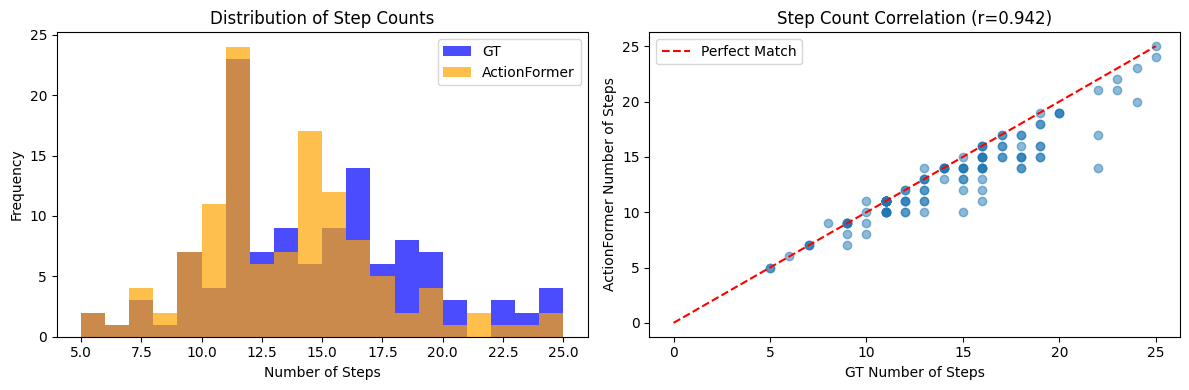

In [10]:
# ==============================================================================
# COMPARISON: GT vs ActionFormer Step Embeddings Statistics
# ==============================================================================

import matplotlib.pyplot as plt

def compare_embedding_stats(gt_data, pred_data, method_name):
    """Compare statistics of step embeddings between GT and predicted boundaries."""

    # Get common recordings
    common_recs = set(gt_data.keys()) & set(pred_data.keys())

    gt_num_steps = []
    pred_num_steps = []

    for rec_id in common_recs:
        gt_num_steps.append(gt_data[rec_id]['num_steps'])
        pred_num_steps.append(pred_data[rec_id]['num_steps'])

    print(f"\n{'='*60}")
    print(f"Comparison: GT vs {method_name}")
    print(f"{'='*60}")
    print(f"Common recordings: {len(common_recs)}")
    print(f"\nNumber of Steps:")
    print(f"  GT:         mean={np.mean(gt_num_steps):.1f}, std={np.std(gt_num_steps):.1f}")
    print(f"  {method_name}: mean={np.mean(pred_num_steps):.1f}, std={np.std(pred_num_steps):.1f}")

    # Correlation
    corr = np.corrcoef(gt_num_steps, pred_num_steps)[0, 1]
    print(f"\nCorrelation (GT vs {method_name} step counts): {corr:.3f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(gt_num_steps, bins=20, alpha=0.7, label='GT', color='blue')
    axes[0].hist(pred_num_steps, bins=20, alpha=0.7, label=method_name, color='orange')
    axes[0].set_xlabel('Number of Steps')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Step Counts')
    axes[0].legend()

    # Scatter
    axes[1].scatter(gt_num_steps, pred_num_steps, alpha=0.5)
    max_val = max(max(gt_num_steps), max(pred_num_steps))
    axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect Match')
    axes[1].set_xlabel('GT Number of Steps')
    axes[1].set_ylabel(f'{method_name} Number of Steps')
    axes[1].set_title(f'Step Count Correlation (r={corr:.3f})')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'step_comparison_gt_vs_{method_name.lower()}.png', dpi=150)
    plt.show()

    return corr


# Run comparison if data is available
if 'gt_data' in dir() and gt_data:
    print("\nStep Embedding Statistics")

    if 'af_data' in dir() and af_data:
        compare_embedding_stats(gt_data, af_data, "ActionFormer")

    if 'cl_data' in dir() and cl_data:
        compare_embedding_stats(gt_data, cl_data, "Clustering")
else:
    print("Run the embedding extraction cell first")